In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import ConstantModel, PersistenceModel, ClimateologyModel, NodeLSTMModel, NodeGRUModel, GATv2Model, SpatialGNNModel, GATv2PLUSModel

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23501062/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [2]:
shallowdata        = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
deepdataloader     = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdataloader    = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

In [6]:
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }



In [7]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')

zeroes = ConstantModel(shallowdata, name = 'zeromodel')
zeroes.set_model_hparams(0)
zeroes.forecast()
ones   = ConstantModel(shallowdata, name = 'onemodel')
ones.set_model_hparams(1)
ones.forecast()

from src.models import NodeRFModel

rf = NodeRFModel(shallowdata, verbose = -1)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators = 1)
rf.train()
rf.forecast('test')
raw_f3 = rf.show_forecasts([26], 'test')




==                     plus                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.5431, val loss: 0.7794 ✓ (new best)
Epoch 002 train loss: 0.5180, val loss: 0.7357 ✓ (new best)
Epoch 003 train loss: 0.5058, val loss: 0.7027 ✓ (new best)
Epoch 004 train loss: 0.4976, val loss: 0.6741 ✓ (new best)
Epoch 005 train loss: 0.4939, val loss: 0.6383 ✓ (new best)
Epoch 006 train loss: 0.4819, val loss: 0.6025 ✓ (new best)
Epoch 007 train loss: 0.4805, val loss: 0.5760 ✓ (new best)
Epoch 008 train loss: 0.4731, val loss: 0.5366 ✓ (new best)
Epoch 009 train loss: 0.4726, val loss: 0.5305 ✓ (new best)
Epoch 010 train loss: 0.4604, val loss: 0.4872 ✓ (new best)
Epoch 011 train loss: 0.4587, val loss: 0.4842 ✓ (new best)
Epoch 012 train loss: 0.4425, val loss: 0.4537 ✓ (new best)
Epoch 013 train loss: 0.4547, val loss: 0.4666 (patience: 1/20)
Epoch 014 train loss: 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 099 train loss: 0.3078, val loss: 0.3518 (patience: 14/20)
lr has been updated from 2.50e-05 to 1.25e-05
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 221.40it/s]


Test loss: 0.5583
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

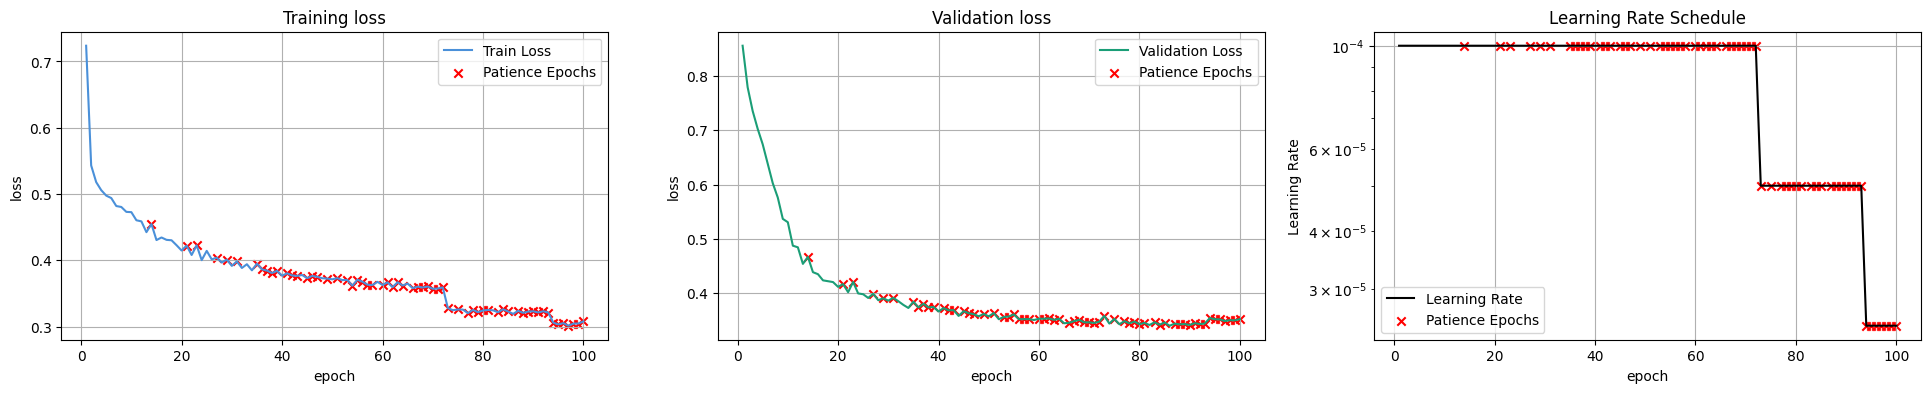

In [8]:
plus = GATv2PLUSModel(graphdataloader, name = 'plus', verbose = 10)
plus.set_model_hparams()
plus.set_global_hparams(**global_hparams)
plus.train()
plus.forecast('test')
plus.show_forecasts(26)


==                    plus2                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 001 train loss: 0.5618, val loss: 0.7587 ✓ (new best)
Epoch 002 train loss: 0.5370, val loss: 0.7182 ✓ (new best)
Epoch 003 train loss: 0.5236, val loss: 0.6901 ✓ (new best)
Epoch 004 train loss: 0.5171, val loss: 0.6607 ✓ (new best)
Epoch 005 train loss: 0.5109, val loss: 0.6351 ✓ (new best)
Epoch 006 train loss: 0.5060, val loss: 0.6115 ✓ (new best)
Epoch 007 train loss: 0.5009, val loss: 0.5851 ✓ (new best)
Epoch 008 train loss: 0.4922, val loss: 0.5586 ✓ (new best)
Epoch 009 train loss: 0.4875, val loss: 0.5386 ✓ (new best)
Epoch 010 train loss: 0.4849, val loss: 0.5224 ✓ (new best)
Epoch 011 train loss: 0.4789, val loss: 0.5016 ✓ (new best)
Epoch 012 train loss: 0.4782, val loss: 0.4867 ✓ (new best)
Epoch 013 train loss: 0.4602, val loss: 0.4717 ✓ (new best)
Epoch 014 train loss: 0.46

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 099 train loss: 0.3059, val loss: 0.3425 (patience: 14/20)
lr has been updated from 2.50e-05 to 1.25e-05
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 236.69it/s]


Test loss: 0.5595
forecasted ✓


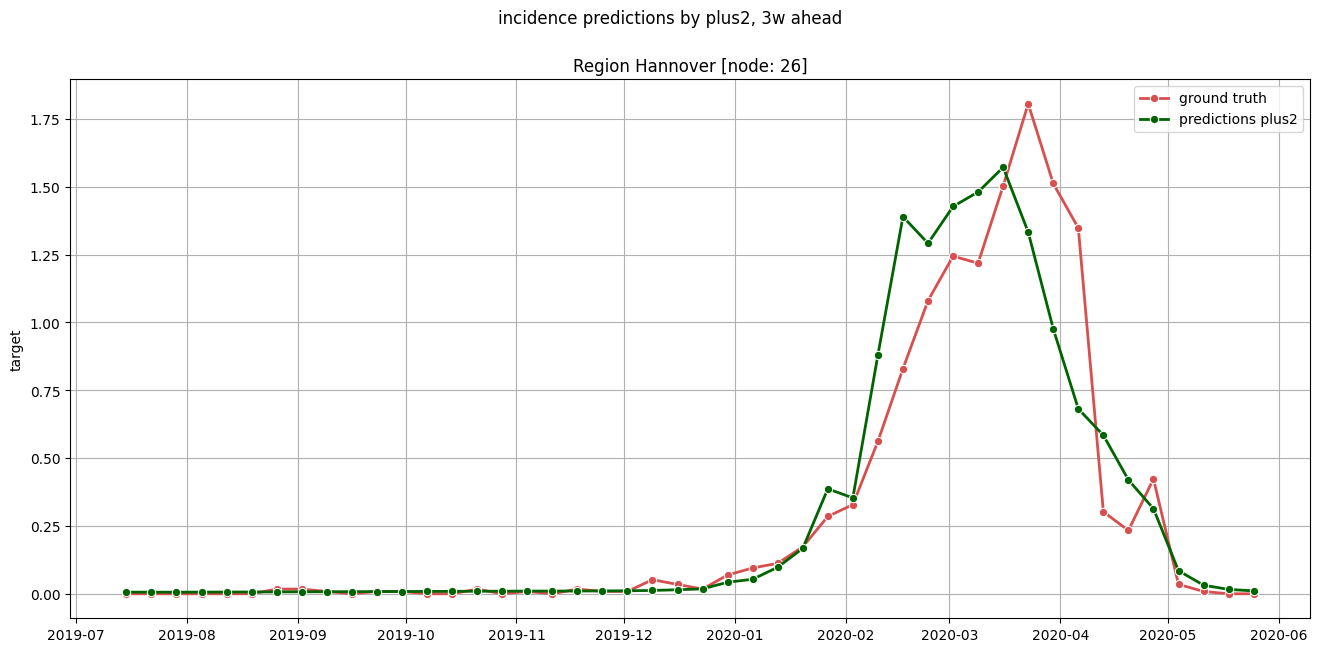

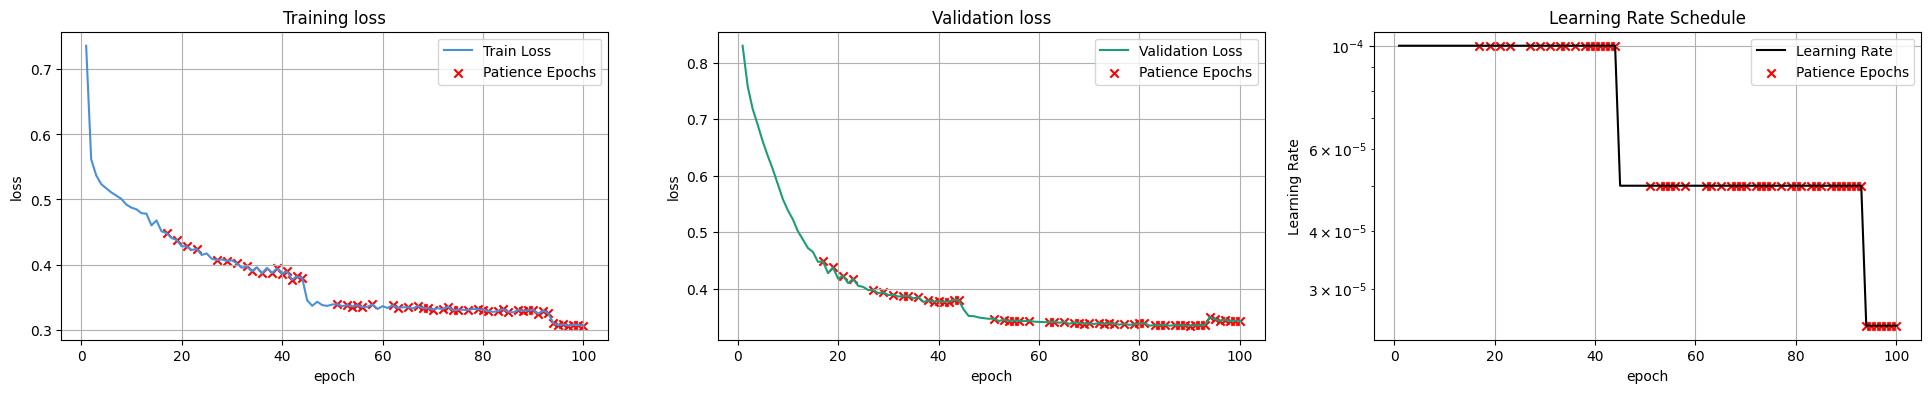

In [13]:
graphdataloader2    = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()

plus2 = GATv2PLUSModel(graphdataloader2, name = 'plus2', verbose = 10)
plus2.set_model_hparams()
plus2.set_global_hparams(**global_hparams)
plus2.train()
plus2.forecast('test')
plus2.show_forecasts(26)

plus2.show_forecasts(26).show()

## LSTM


==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 4, 1), y=(400, 1))


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 463.86it/s]


Test loss: 1.3642
forecasted ✓

==                     gcn                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))


...

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 457.48it/s]

Test loss: 1.5425
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

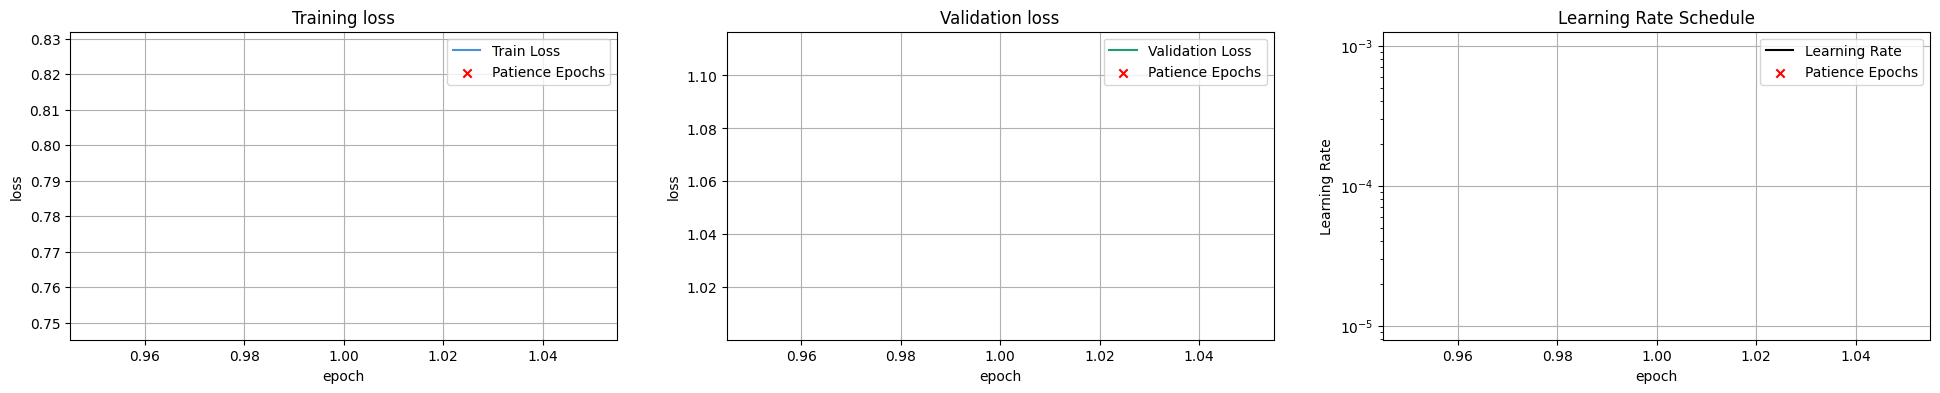

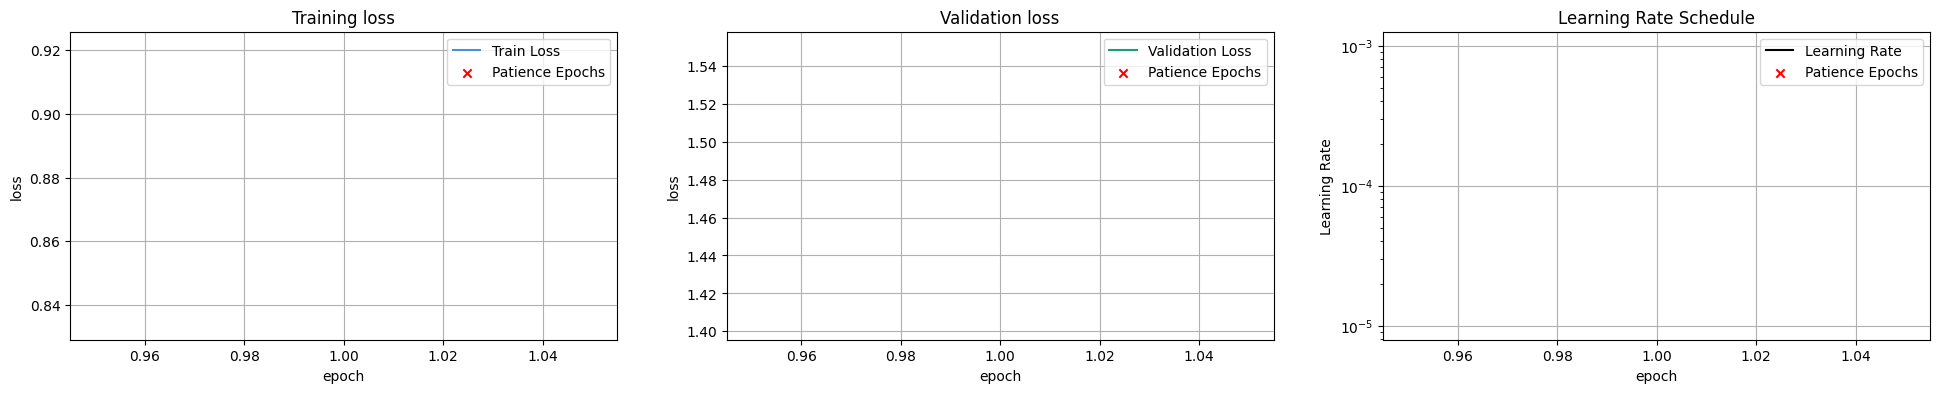

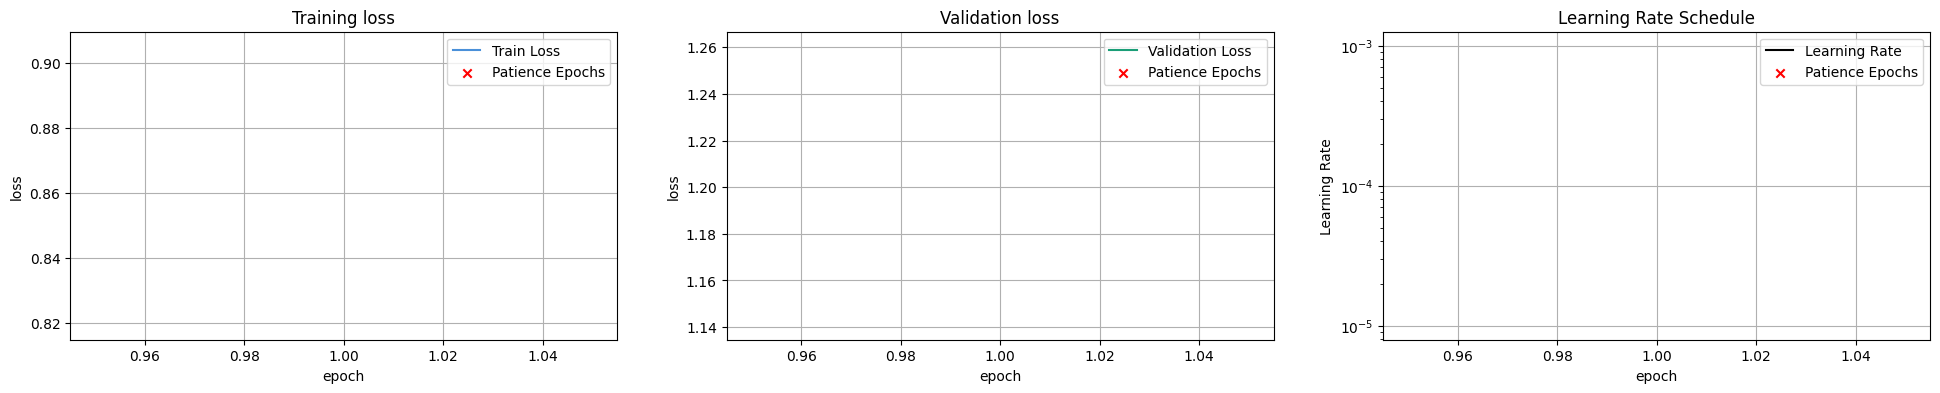

In [6]:
lstm = NodeLSTMModel(deepdataloader, name = 'lstm', verbose = 10)
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26)

gcn = SpatialGNNModel(graphdataloader, name = 'gcn', verbose = 10)
gcn.set_model_hparams(hidden_size=128)
gcn.set_global_hparams(**global_hparams)
gcn.train()
gcn.forecast('test')
gcn.show_forecasts(26)

gat = GATv2Model(graphdataloader, name = 'gat', verbose = 10)
gat.set_model_hparams(hidden_size=128)
gat.set_global_hparams(**global_hparams)
gat.train()
gat.forecast('test')
gat.show_forecasts(26)

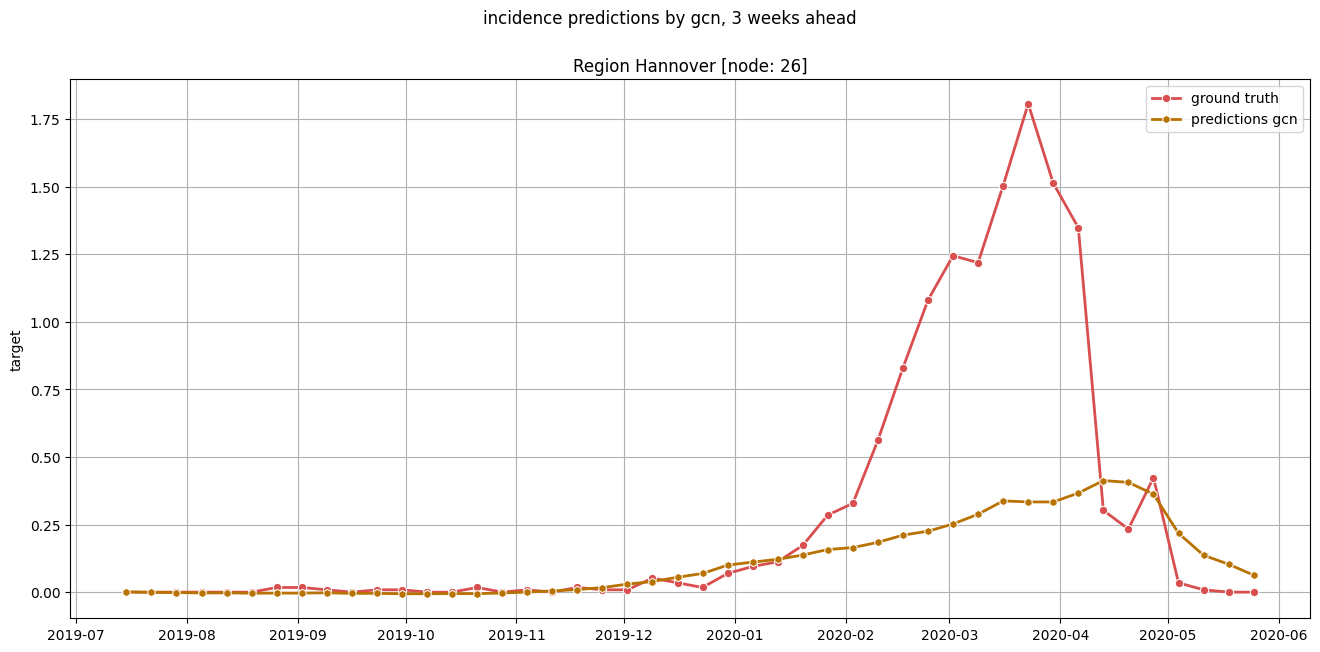

In [7]:
gcn.show_forecasts(26).show()


==                     gru                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 4, 1), y=(400, 1))


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 915.55it/s]


Test loss: 1.1915
forecasted ✓


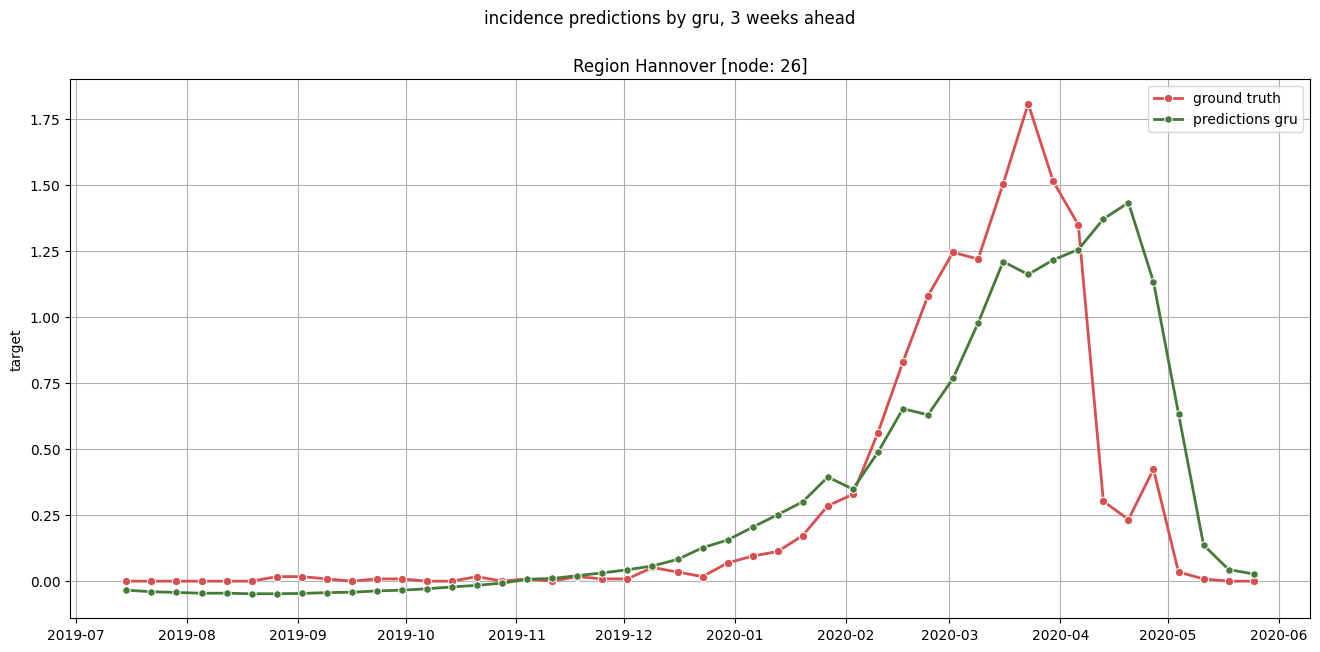

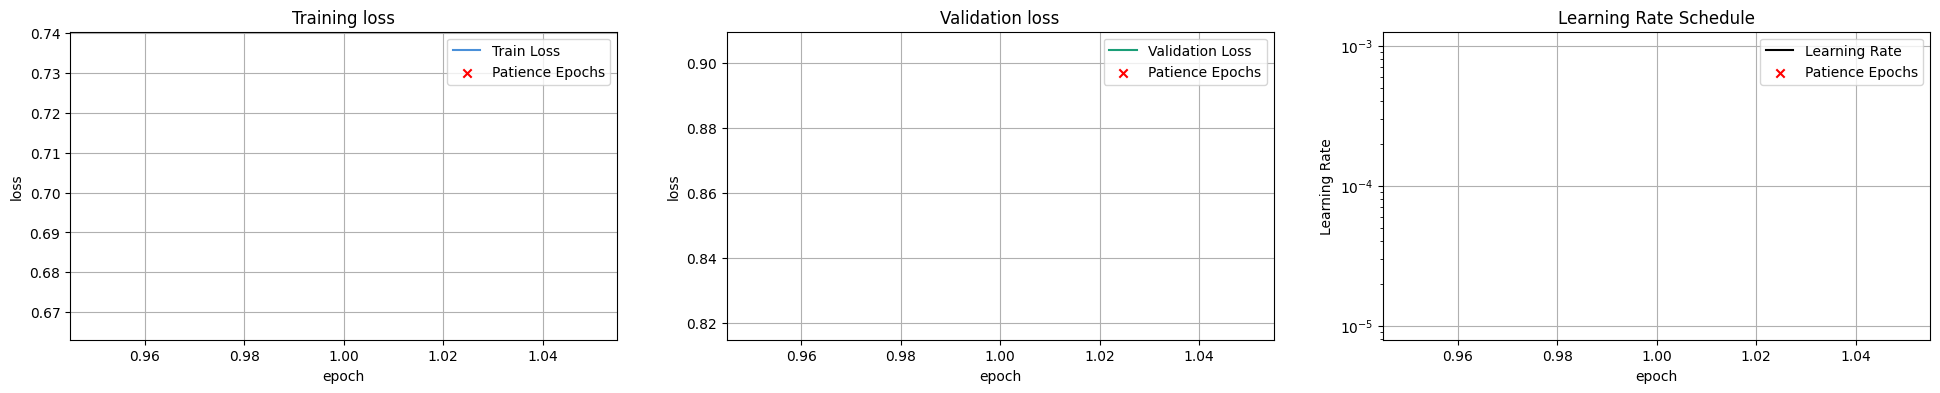

In [8]:
gru = NodeGRUModel(deepdataloader, name = 'gru', verbose = 2)
gru.set_model_hparams(hidden_size=128)
gru.set_global_hparams(**global_hparams)
gru.train()
gru.forecast('test')
gru.show_forecasts(26).show()

computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:03<00:00,  1.53it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

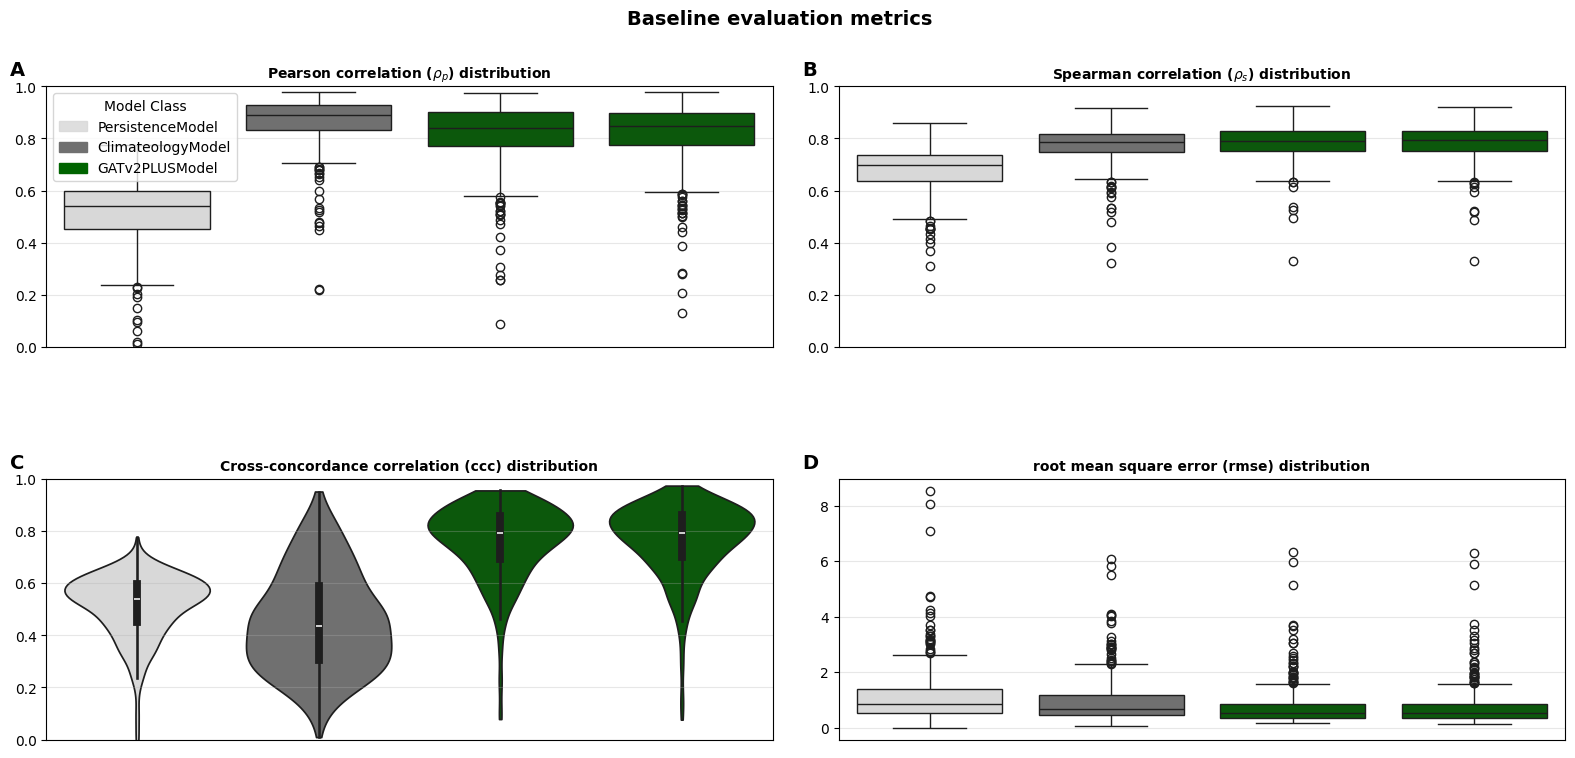

In [15]:
from src.evaluation import Evaluator
evaluation = Evaluator(models = [persistence, climateology, plus, plus2]).add_evaluation()
f_merged_raw    = evaluation.plotter.plot_metric_compilation(subfig_size = (8,4), plot_types=['box','box','violin','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Baseline evaluation metrics', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([])
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)             
    )
f_merged.show()

## GNNs

In [ ]:
# spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'gcn-identity_graph')
# spatial_model1.set_model_hparams()
# spatial_model1.set_global_hparams(**global_hparams)
# spatial_model1.train(verbose = 0, show_loss=False)
# spatial_model1.forecast('test')
# spatial_model1.show_forecasts(26)

# spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'gcn-boolean_neighbors')
# spatial_model2.set_model_hparams()
# spatial_model2.set_global_hparams(**global_hparams)
# spatial_model2.train(verbose = 0, show_loss=False)
# spatial_model2.forecast('test')
# spatial_model2.show_forecasts(26)


st1 = GATv2Model(graphdataloader_1, name = 'undertrained_gatv2')
st1.set_model_hparams()
st1.set_global_hparams(**global_hparams)
st1.train()
st1.forecast('test')
st1.show_forecasts(26)

# st2 = GATv2Model(graphdataloader_2, name = 'gatv2-2')
# st2.set_model_hparams()
# st2.set_global_hparams(**global_hparams)
# st2.train(verbose = 0, show_loss=False)
# st2.forecast('test')
# st2.show_forecasts(26)

# st3 = GATv2Model(graphdataloader_3, name = 'gatv2-3')
# st3.set_model_hparams()
# st3.set_global_hparams(**global_hparams)
# st3.train(verbose = 0, show_loss=False)
# st3.forecast('test')
# st3.show_forecasts(26)


# st4 = GATv2Model(graphdataloader_10, name = 'gatv2-10')
# st4.set_model_hparams()
# st4.set_global_hparams(**global_hparams)
# st4.train(verbose = 0, show_loss=False)
# st4.forecast('test')
# st4.show_forecasts(26)


# st5 = GATv2Model(graphdataloader_14, name = 'gatv2-14')
# st5.set_model_hparams()
# st5.set_global_hparams(**global_hparams)
# st5.train(verbose = 0, show_loss=False)
# st5.forecast('test')
# st5.show_forecasts(26)



<Fig(legend, ticks, labels)>

In [ ]:
model = GATv2Model.load('saved_models/my_trained_model.pt')
model.forecast('test')

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/modelmanager.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  save_dict = torch.load(filepath, map

✓ Model loaded: saved_models/my_trained_model.pt


GATv2Model(name='undertrained_gatv2')

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

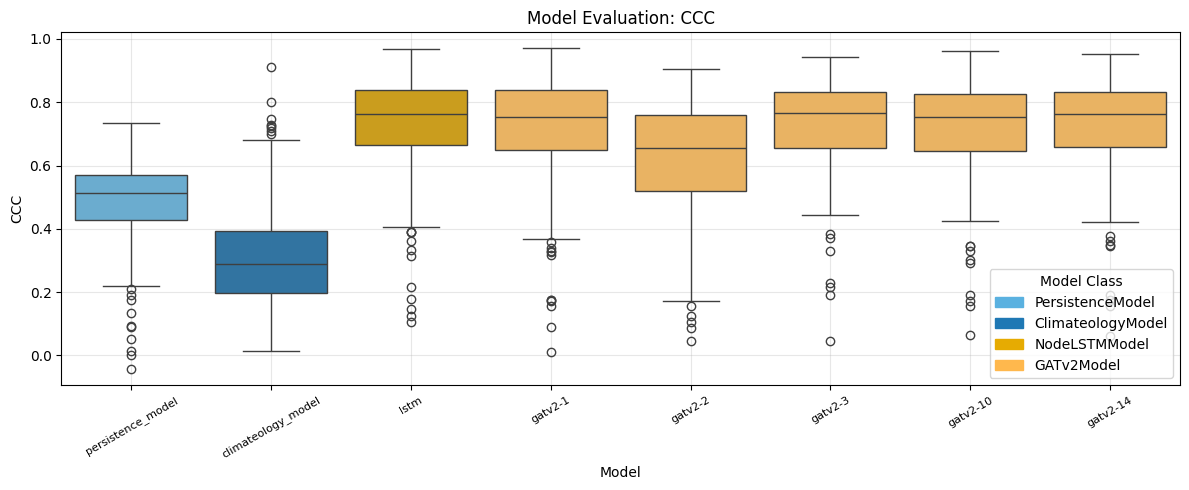

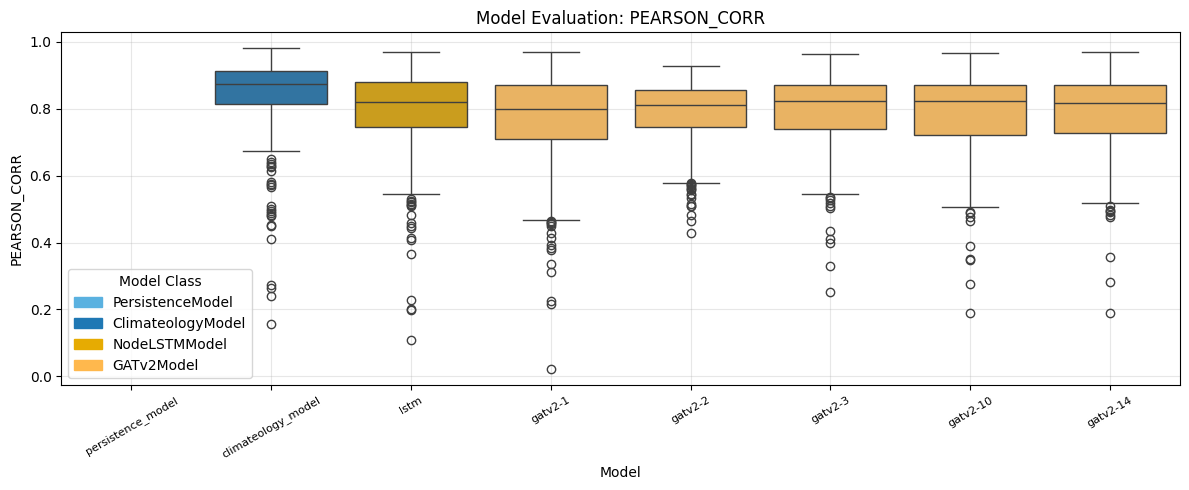

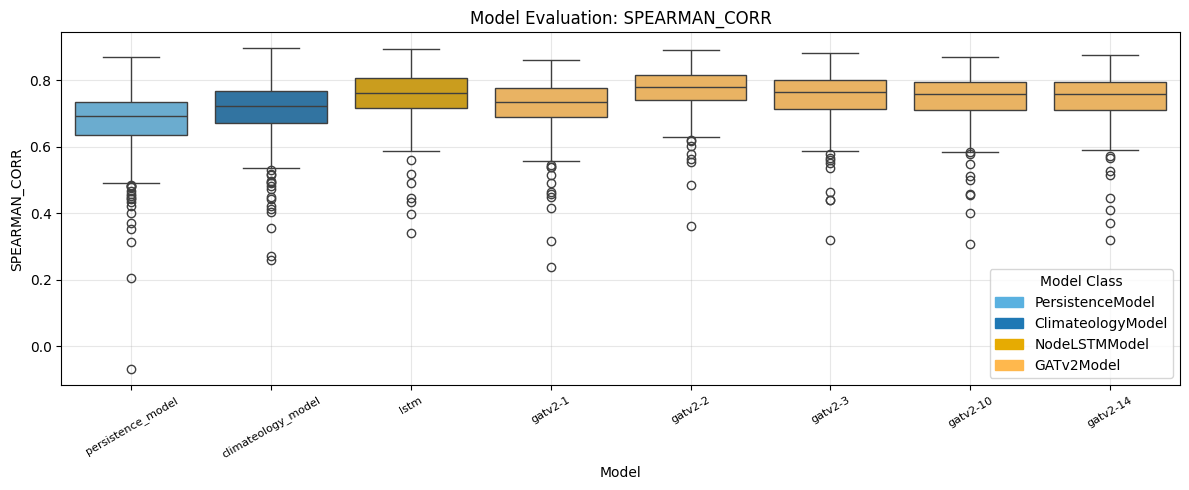

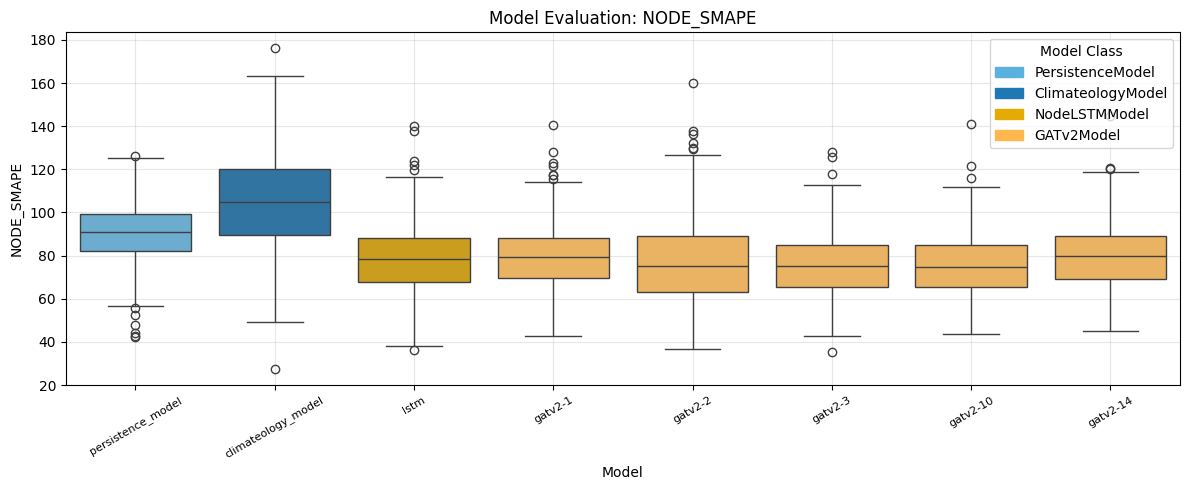

In [ ]:
evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('pearson_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('spearman_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('node_smape', horizon = 'horizon_0', plot_type='box')